In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/finger-print-based-blood-group-dataset/dataset_blood_group/AB-/cluster_5_5324.BMP
/kaggle/input/finger-print-based-blood-group-dataset/dataset_blood_group/AB-/cluster_5_3382.BMP
/kaggle/input/finger-print-based-blood-group-dataset/dataset_blood_group/AB-/cluster_5_1398.BMP
/kaggle/input/finger-print-based-blood-group-dataset/dataset_blood_group/AB-/cluster_5_1142.BMP
/kaggle/input/finger-print-based-blood-group-dataset/dataset_blood_group/AB-/cluster_5_5002.BMP
/kaggle/input/finger-print-based-blood-group-dataset/dataset_blood_group/AB-/cluster_5_2646.BMP
/kaggle/input/finger-print-based-blood-group-dataset/dataset_blood_group/AB-/cluster_5_3476.BMP
/kaggle/input/finger-print-based-blood-group-dataset/dataset_blood_group/AB-/cluster_5_1613.BMP
/kaggle/input/finger-print-based-blood-group-dataset/dataset_blood_group/AB-/cluster_5_5593.BMP
/kaggle/input/finger-print-based-blood-group-dataset/dataset_blood_group/AB-/cluster_5_2975.BMP
/kaggle/input/finger-print-based-blood-g

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image dimensions
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32

# Directory paths
train_dir = '/kaggle/input/finger-print-based-blood-group-dataset/dataset_blood_group'

# Data augmentation and preprocessing for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # Use 20% of the data for validation
)

# Train generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

# Validation generator
validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# Low accuracy model with Input layer
def create_low_accuracy_model():
    model = tf.keras.models.Sequential([
        tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
        tf.keras.layers.Conv2D(16, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(train_generator.num_classes, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Create the low accuracy model
low_acc_model = create_low_accuracy_model()

# Train the low accuracy model
history_low_acc = low_acc_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_steps=validation_generator.samples // BATCH_SIZE
)

# Evaluate the low accuracy model
low_acc_eval = low_acc_model.evaluate(validation_generator)
print(f"Low Accuracy Model - Loss: {low_acc_eval[0]}, Accuracy: {low_acc_eval[1]}")


Found 4803 images belonging to 8 classes.
Found 1197 images belonging to 8 classes.
Epoch 1/10


/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


150/150 ━━━━━━━━━━━━━━━━━━━━ 42s 260ms/step - accuracy: 0.4609 - loss: 1.5150 - val_accuracy: 0.7466 - val_loss: 0.6458
Epoch 2/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 375us/step - accuracy: 0.7188 - loss: 0.7197 - val_accuracy: 0.9231 - val_loss: 0.3335
Epoch 3/10


/opt/conda/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


150/150 ━━━━━━━━━━━━━━━━━━━━ 33s 219ms/step - accuracy: 0.8672 - loss: 0.3723 - val_accuracy: 0.8378 - val_loss: 0.3905
Epoch 4/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 284us/step - accuracy: 1.0000 - loss: 0.0814 - val_accuracy: 0.8462 - val_loss: 0.3464
Epoch 5/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 33s 219ms/step - accuracy: 0.9318 - loss: 0.1888 - val_accuracy: 0.8682 - val_loss: 0.3330
Epoch 6/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 936us/step - accuracy: 0.9375 - loss: 0.1397 - val_accuracy: 0.9231 - val_loss: 0.2172
Epoch 7/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 33s 220ms/step - accuracy: 0.9702 - loss: 0.1092 - val_accuracy: 0.8547 - val_loss: 0.4113
Epoch 8/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 840us/step - accuracy: 0.9375 - loss: 0.1656 - val_accuracy: 0.8462 - val_loss: 0.5664
Epoch 9/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 34s 222ms/step - accuracy: 0.9867 - loss: 0.0584 - val_accuracy: 0.8294 - val_loss: 0.5045
Epoch 10/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 594us/step - accuracy: 0.9375 - loss: 0.1708 - val_ac

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image dimensions
IMG_HEIGHT = 64
IMG_WIDTH = 64
BATCH_SIZE = 32

# Directory paths (adjust as needed)
train_dir = '/kaggle/input/finger-print-based-blood-group-dataset/dataset_blood_group'

# Data augmentation and preprocessing for training
train_datagen = ImageDataGenerator(
    rescale=1./255,  # Normalize pixel values to [0,1]
    validation_split=0.2  # Use 20% of the data for validation
)

# Train generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'  # Training data subset
)

# Validation generator
validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'  # Validation data subset
)

# High accuracy model: Deep CNN
def create_high_accuracy_model():
    model = tf.keras.models.Sequential([
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Conv2D(256, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.Dropout(0.5),  # Regularization to prevent overfitting
        tf.keras.layers.Dense(train_generator.num_classes, activation='softmax')
    ])

    # Compile the model
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Create the model
high_acc_model = create_high_accuracy_model()

# Train the model
history_high_acc = high_acc_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=100,  # Adjust the number of epochs based on your preference
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_steps=validation_generator.samples // BATCH_SIZE
)

# Evaluate the model on validation data
high_acc_eval = high_acc_model.evaluate(validation_generator)
print(f"High Accuracy Model - Loss: {high_acc_eval[0]}, Accuracy: {high_acc_eval[1]}")


Found 4803 images belonging to 8 classes.
Found 1197 images belonging to 8 classes.
Epoch 1/100


/opt/conda/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


150/150 ━━━━━━━━━━━━━━━━━━━━ 24s 141ms/step - accuracy: 0.3143 - loss: 1.7224 - val_accuracy: 0.7466 - val_loss: 0.6877
Epoch 2/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 298us/step - accuracy: 0.7188 - loss: 0.6526 - val_accuracy: 0.8462 - val_loss: 0.5495
Epoch 3/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 22s 145ms/step - accuracy: 0.7856 - loss: 0.5928 - val_accuracy: 0.8091 - val_loss: 0.5059
Epoch 4/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 231us/step - accuracy: 0.7500 - loss: 0.5039 - val_accuracy: 0.7692 - val_loss: 0.5442
Epoch 5/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 40s 140ms/step - accuracy: 0.8238 - loss: 0.4593 - val_accuracy: 0.8285 - val_loss: 0.4571
Epoch 6/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7500 - loss: 0.8044 - val_accuracy: 1.0000 - val_loss: 0.1253
Epoch 7/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 22s 145ms/step - accuracy: 0.8624 - loss: 0.3879 - val_accuracy: 0.8573 - val_loss: 0.3689
Epoch 8/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 228us/step - accuracy: 0.8125 - loss: 0.4344 - va

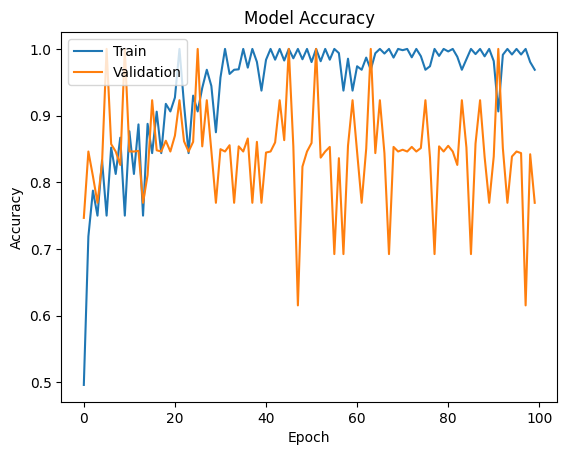

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
def plot_accuracy(history):
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.show()

# Call the function to display the accuracy graph
plot_accuracy(history_high_acc)
